<h2>Projeto de Análise e Previsão de Custos de Saúde.</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
caminho = "Datasets/insurance.csv"

df = pd.read_csv(caminho)

print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

O dataset possui 1338 linhas e 7 colunas.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print("Valores Nulos:")
df.isnull().sum()

Valores Nulos:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<h2>Primeiras Dúvidas</h2>

In [6]:
#Variável sex
df['sex'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

_________________________________________________________________________________________
 Variável BMI = É a sigla em inglês para Body Mass Index, ou seja, o índice de massa corporal (IMC). Verificando o portal nacional da saúde entendemos que:

 <18,5 = Magreza; 
 
 18,5 e 24,9 = Saudável;
 
 25 e 29,9 = Sobrepeso;
 
 30 e 34,9 = Obesidade Grau 1;
 
 35 e 39,9 = Obesidade Grau 2;
 
 40>= Obesidade Grau 3

 Obs = a média e a mediana do dataset gira em torno de 30. O que faz sentido num dataset com informações capturadas no EUA, onde a aproximadamente 42% dos adultos americanos são classificados com obesidade (IMC > 30).

 _________________________________________________________________________________________


_________________________________________________________________________________________
Variavel charges = Custos médico individual cobrado pelo plano de saúde. A média está em 13.270, mas temos valores de até 63.770
_________________________________________________________________________________________

<h2>Análise Exploratória</h2>

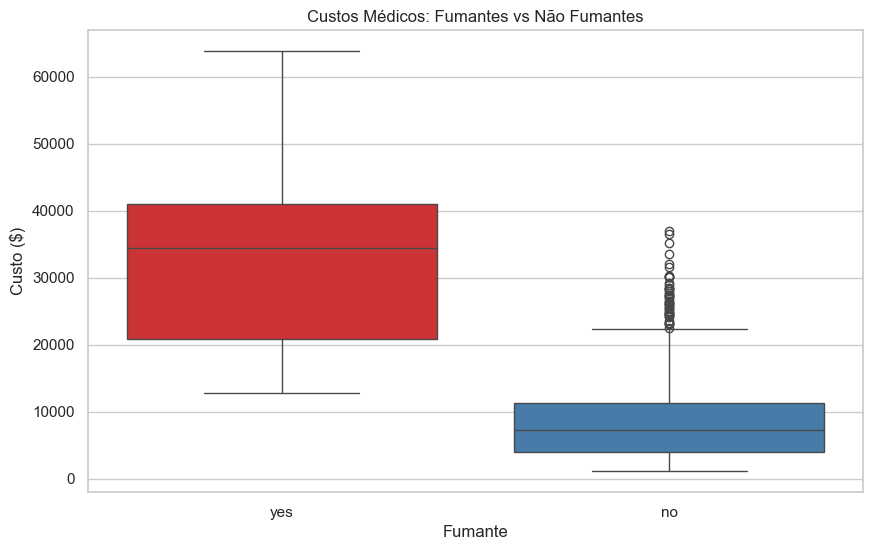

In [7]:
# Qual o impacto do tabagismo no custo?

plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set1')
plt.title('Custos Médicos: Fumantes vs Não Fumantes')
plt.xlabel('Fumante')
plt.ylabel('Custo ($)')
plt.show()


> **Resposta:** O custo mediano de um fumante é quase **4x maior** que o de um não fumante.

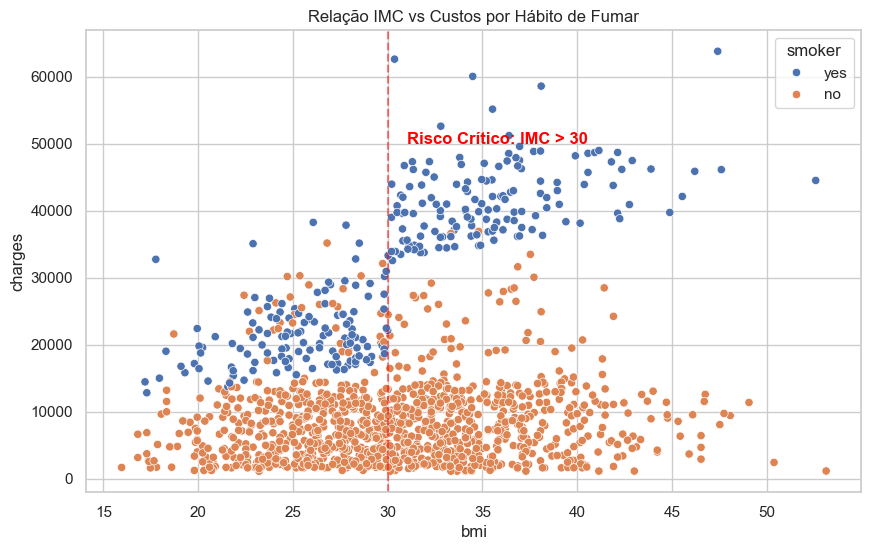

In [8]:
#Vamos relacionar essa duas variáveis ao BMI/IMC

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)


plt.axvline(30, color='red', linestyle='--', alpha=0.5)
plt.text(31, 50000, 'Risco Crítico: IMC > 30', color='red', fontweight='bold')

plt.title('Relação IMC vs Custos por Hábito de Fumar')
plt.show()

> **Resposta:** Podemos notar que a váriavel fumente(smoker) tem uma alta influência sobre o custo, muitas vezes maior que o IMC

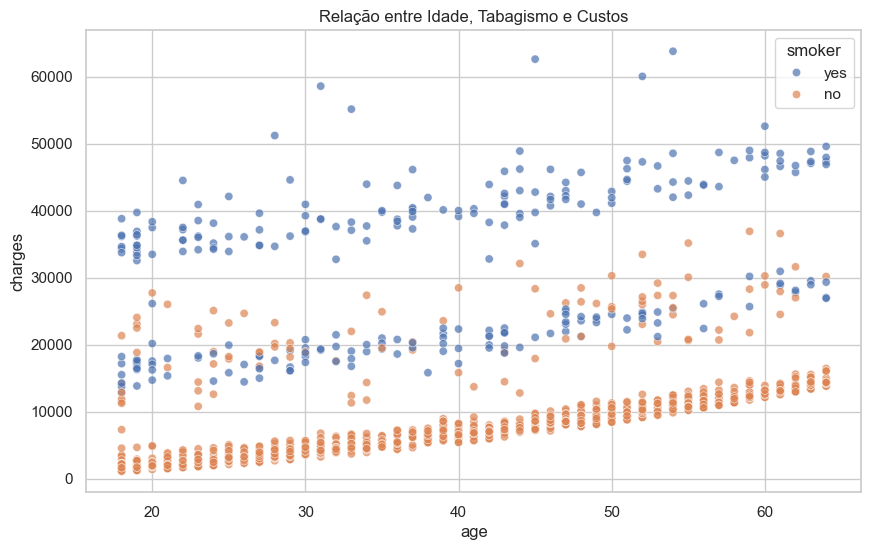

In [9]:
#Vamos ver a variável idade:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('Relação entre Idade, Tabagismo e Custos')
plt.show()


> **Resposta:** Mesmo entre os não fumantes reparamos que há uma leve regressão linear positiva, ou seja, a idade também afeta o custo como esperado


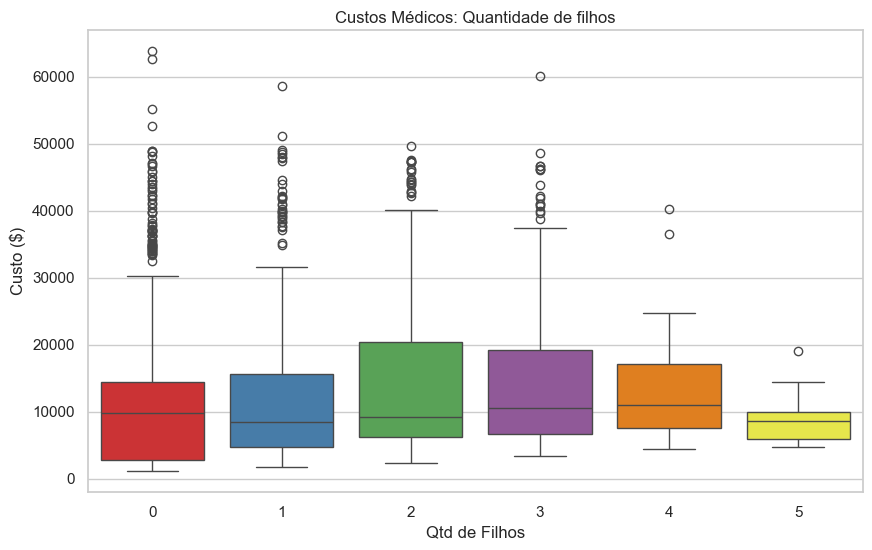

In [10]:
# Qual o impacto da quantidade de crianças?

plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=df, palette='Set1')
plt.title('Custos Médicos: Quantidade de filhos')
plt.xlabel('Qtd de Filhos')
plt.ylabel('Custo ($)')
plt.show()


> **Resposta:** Analisando a variável de número de filhos, temos pouca variação, principalmente em relação a fumantes.

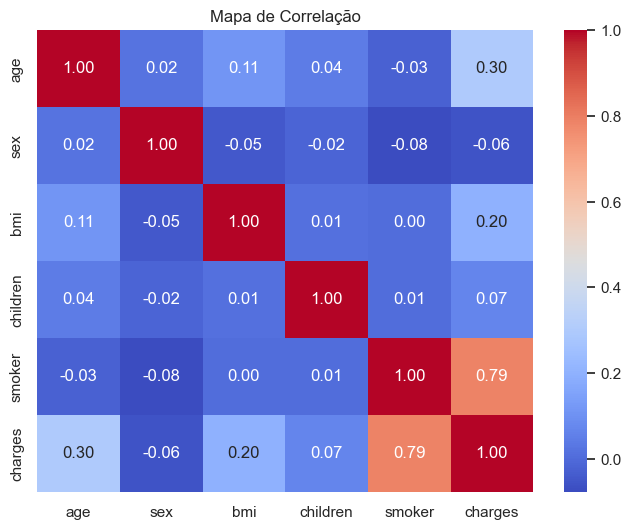

In [11]:
#Vamos ver um correlação geral entre as variáveis:

#Copaindo o dataset e transformando as variávies em númericas
df_corr = df.copy()
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
df_corr['sex'] = df_corr['sex'].map({'female': 1, 'male': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlação')
plt.show()

> **Resposta:** O foco aqui é a última coluna ou a última linha, como as variáveis se comportam com o custo (charges).
>
> **Fumantes (smoker):** De longe a variável de maior impacto no custo
> 
> **Idade (age):** Tem uma variação positiva interessante, ou seja, envelhecer aumenta o custo
> 
> **IMC (bmi):** Sozinho tem pouca relevancia, mas somado a condição de fumante ou idoso pode causar grande impacto no custo

<h2>Previsão</h2>

In [12]:
#mudando novamente as colunas smoker e sex para númericas

df_ml = df.copy()
df_ml['smoker'] = df_ml['smoker'].map({'yes': 1, 'no': 0})
df_ml['sex'] = df_ml['sex'].map({'female': 1, 'male': 0})
df_ml.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [13]:
#trabalhando a coluna região

df_ml = pd.get_dummies(df_ml, columns=['region'], drop_first=True)


print("Colunas após o Encoding:")
print(df_ml.columns)
df_ml.head()

Colunas após o Encoding:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [14]:
df['region'].unique() ## Caso as três regiões sejam False, quer dizer: northeast

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [17]:
#separando nossos dados para treinamento

from sklearn.model_selection import train_test_split

X = df_ml.drop('charges', axis=1) #salvamos a tabela na variável X, menos a coluna alvo que é charges.
y = df_ml['charges'] #salvamos nossa coluna alvo em y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treinaremos com {len(X_train)} amostras e testaremos com {len(X_test)} amostras.")

Treinaremos com 1070 amostras e testaremos com 268 amostras.


-----------------------------------------------------------------------------------------------------------------------------------------------------
**Random Forest (Floresta Aleatória)** é um algoritmo de aprendizado de máquina supervisionado, utilizado para classificação e regressão, que combina múltiplas árvores de decisão para criar um modelo mais preciso e estável

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)


modelo_rf.fit(X_train, y_train)

previsoes = modelo_rf.predict(X_test)

mae = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print(f"Erro Médio Absoluto (MAE): ${mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

Erro Médio Absoluto (MAE): $2529.06
Coeficiente de Determinação (R²): 0.8666


> **Resposta:** O modelo teve um acerto de 86% e uma média de erro de 2.529,06

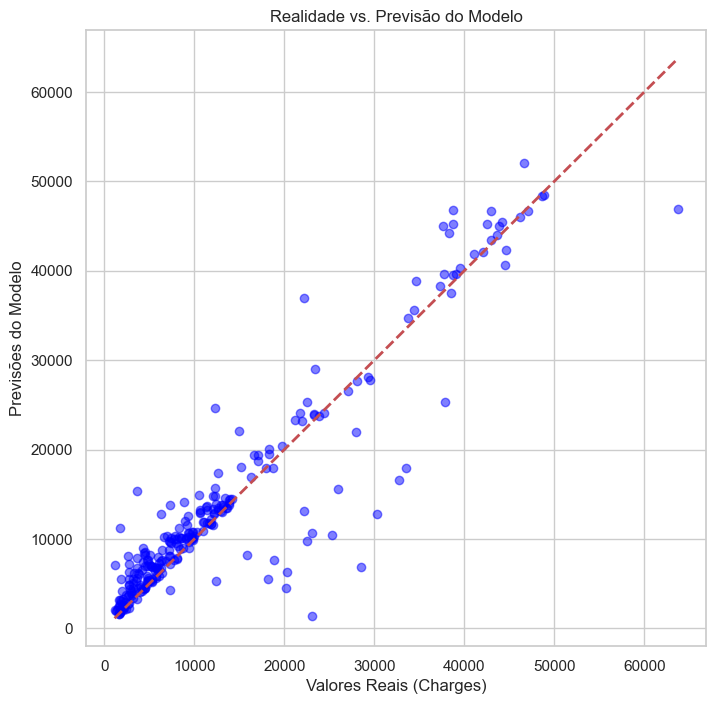

In [20]:
#Vamos ver o grafico entre os valores reais e o modelo de previsão

plt.figure(figsize=(8, 8))
plt.scatter(y_test, previsoes, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (Charges)')
plt.ylabel('Previsões do Modelo')
plt.title('Realidade vs. Previsão do Modelo')
plt.show()

In [23]:
def prever_seguro(idade, sexo, imc, filhos, fumante, regiao):
    
    dados = {
        'age': [idade],
        'sex': [1 if sexo == 'feminino' else 0],
        'bmi': [imc],
        'children': [filhos],
        'smoker': [1 if fumante == 'sim' else 0],
        'region_northwest': [1 if regiao == 'northwest' else 0],
        'region_southeast': [1 if regiao == 'southeast' else 0],
        'region_southwest': [1 if regiao == 'southwest' else 0]
    }
    
    novo_cliente = pd.DataFrame(dados)
    preco = modelo_rf.predict(novo_cliente)
    return print(f"O valor estimado do seguro é: ${preco[0]:.2f}")

In [35]:
prever_seguro(30,'masculino',27,0,'não','southeast')

O valor estimado do seguro é: $3331.10
